In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [60]:
df = pd.read_csv(r"C:\Users\tb6353\Desktop\DSC592\dsc592_spring26_group_b\data\AppReview.csv")
pd.set_option('display.max_colwidth', 300)
print("Shape : " ,df.shape,end = "\n")
df.head()


Shape :  (111143, 6)


,appID,reviewerName,reviewText,reviewerRating,reviewDate,textAnalytics
0,3,Eric Hansen,"Love it! WELL worth the money for the full version. I came for the ad-blocking, and stayed for everything else. It really is as quick as lightning, super light on system resources, and easy to navigate. I do miss some of the gestures from Chrome (particularly the ""swipe down to view tabs"" gestur...",1.0,42923,NaN
1,3,Jacob N.,"There's an awful bug that doesn't allow you to use the space bar if you want to type a search term from the url box. Ruined the whole experience for me. There's free browsers like Dee Browser that are the same as this one, but without awful bugs. I can't believe this a paid app Full Review",0.4,42976,NaN
2,3,Higgins Family,Would be 5 stars except for the bugs.... For example in incognito tab you cannot type in an address without the cursor jumping out of the field. Had made it unusable Full Review,0.8,43010,NaN
3,3,Rajko Dikmann,"Worked perfect until a few weeks ago. Then browsing experience slowed down/surfing with lightning didn't work anymore. First thought it's my connection, but other apps and browsers worked just fine. Would like to continue to use and support the browser, maybe dev can help. LG G3, Android 6.0 Ful...",0.4,43006,NaN
4,3,Sergei Garcia,"Hands down the best browser on the play store! Even on a flagship device, this ultra lightweight, yet feature packed browser runs laps around bloated browsers like Chrome, Firefox, Opera and Dolphin. 10/10, would recommend Full Review",1.0,42925,NaN


In [61]:
print("Data Types : \n",df.dtypes,end = "\n")

Data Types : 
 appID               int64
reviewerName       object
reviewText         object
reviewerRating    float64
reviewDate          int64
textAnalytics     float64
dtype: object


In [62]:
print("Any Null Values:\n",df.isna().sum())

Any Null Values:
 appID                  0
reviewerName        5303
reviewText             0
reviewerRating         0
reviewDate             0
textAnalytics     110656
dtype: int64


### Critical Imbalance findings in the Dataset

In [63]:
rating_counts = df['reviewerRating'].value_counts().sort_index()
rating_pct = (rating_counts / len(df) * 100).round(2)

summary = pd.DataFrame({'count': rating_counts, 'percent': rating_pct})
print(summary)

                count  percent
reviewerRating                
0.0                71     0.06
0.2             10296     9.26
0.4              5244     4.72
0.6              9160     8.24
0.8             18719    16.84
1.0             67653    60.87


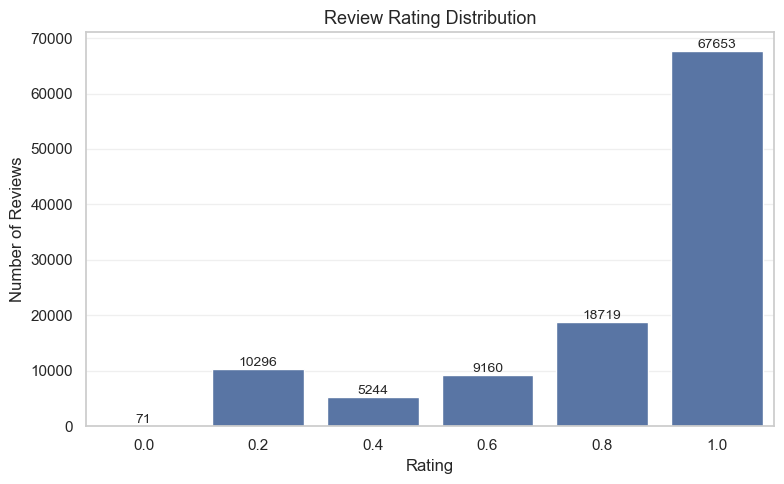

In [64]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
)

plt.title('Review Rating Distribution', fontsize=13)
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, value in enumerate(rating_counts.values):
    ax.text(i, value, str(value), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#### The intial model prediction is biased because the ratings with 1.0 is way more than the ratings with 0.0. with 71 records for 0.0 the model will unable to learn perfectly. 

### Changing the Date Structure

In [65]:
# reviewDate is Excel serial date (days since 1900-01-01)
df['reviewDate_parsed'] = pd.to_datetime(df['reviewDate'], origin='1899-12-30', unit='D')
print("Date range:", df['reviewDate_parsed'].min(), "to", df['reviewDate_parsed'].max())
df[['reviewDate', 'reviewDate_parsed']].head()

Date range: 2009-02-11 00:00:00 to 2017-10-28 00:00:00


,reviewDate,reviewDate_parsed
0,42923,2017-07-07
1,42976,2017-08-29
2,43010,2017-10-02
3,43006,2017-09-28
4,42925,2017-07-09


In [66]:
df.drop(columns = ["reviewDate"],inplace=True)

In [67]:
df.rename(columns = {"reviewDate_parsed" : "reviewDate"}).head()

,appID,reviewerName,reviewText,reviewerRating,textAnalytics,reviewDate
0,3,Eric Hansen,"Love it! WELL worth the money for the full version. I came for the ad-blocking, and stayed for everything else. It really is as quick as lightning, super light on system resources, and easy to navigate. I do miss some of the gestures from Chrome (particularly the ""swipe down to view tabs"" gestur...",1.0,NaN,2017-07-07
1,3,Jacob N.,"There's an awful bug that doesn't allow you to use the space bar if you want to type a search term from the url box. Ruined the whole experience for me. There's free browsers like Dee Browser that are the same as this one, but without awful bugs. I can't believe this a paid app Full Review",0.4,NaN,2017-08-29
2,3,Higgins Family,Would be 5 stars except for the bugs.... For example in incognito tab you cannot type in an address without the cursor jumping out of the field. Had made it unusable Full Review,0.8,NaN,2017-10-02
3,3,Rajko Dikmann,"Worked perfect until a few weeks ago. Then browsing experience slowed down/surfing with lightning didn't work anymore. First thought it's my connection, but other apps and browsers worked just fine. Would like to continue to use and support the browser, maybe dev can help. LG G3, Android 6.0 Ful...",0.4,NaN,2017-09-28
4,3,Sergei Garcia,"Hands down the best browser on the play store! Even on a flagship device, this ultra lightweight, yet feature packed browser runs laps around bloated browsers like Chrome, Firefox, Opera and Dolphin. 10/10, would recommend Full Review",1.0,NaN,2017-07-09


In [69]:
df = df.drop(columns=  "textAnalytics")


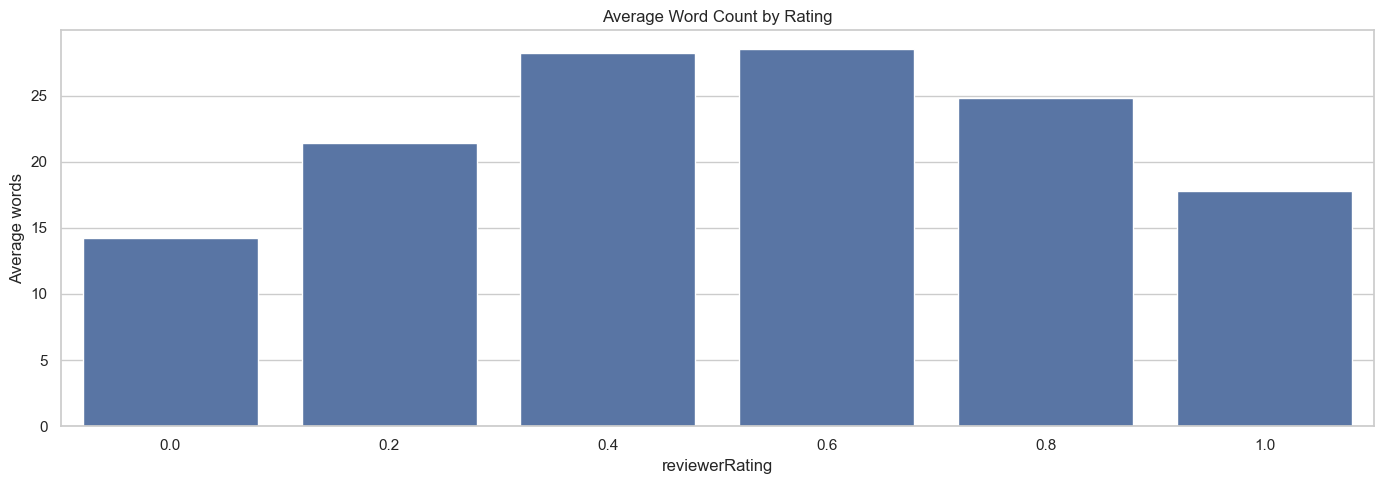

In [70]:
# Compute length per review
df['review_length'] = df['reviewText'].str.len()
df['word_count'] = df['reviewText'].str.split().str.len()

# Average length per rating
length_by_rating = df.groupby('reviewerRating').agg(
    avg_words=('word_count', 'mean')
).round(1)
# Visualize
fig, axes = plt.subplots( figsize=(14, 5))
sns.barplot(data=length_by_rating.reset_index(), x='reviewerRating', y='avg_words')
axes.set_title('Average Word Count by Rating')
axes.set_ylabel('Average words')
plt.tight_layout()
plt.show()

#### WordCloud with Lowest Rating

<Figure size 2000x800 with 0 Axes>

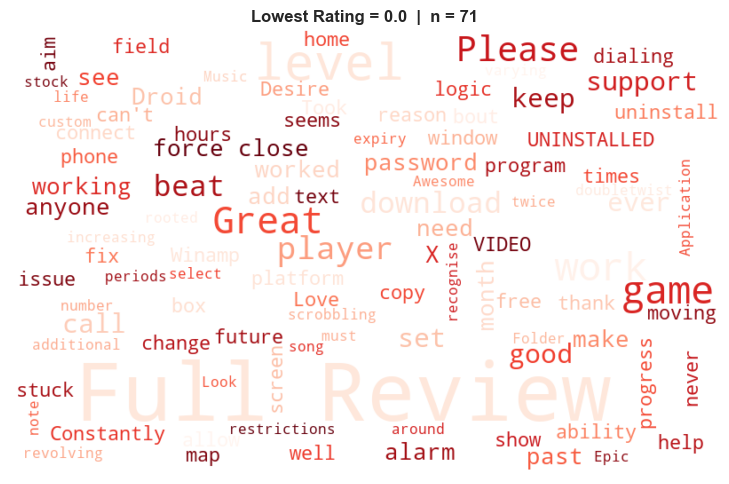

In [83]:

min_rating = df['reviewerRating'].min()

text_low = ' '.join(
    df[df['reviewerRating'] == min_rating]['reviewText'].astype(str).values
)


wc_low = WordCloud(
    width=800,
    height=500,
    background_color='white',
    stopwords=stop_words,
    max_words=100
    colormap='Reds',
    random_state=42
).generate(text_low)

plt.figure(figsize=(8, 5))
plt.imshow(wc_low, interpolation='bilinear')
plt.title(f'Lowest Rating = {min_rating}  |  n = {len(df[df["reviewerRating"]==min_rating]):,}',
          fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

#### WordCloud with highest rating

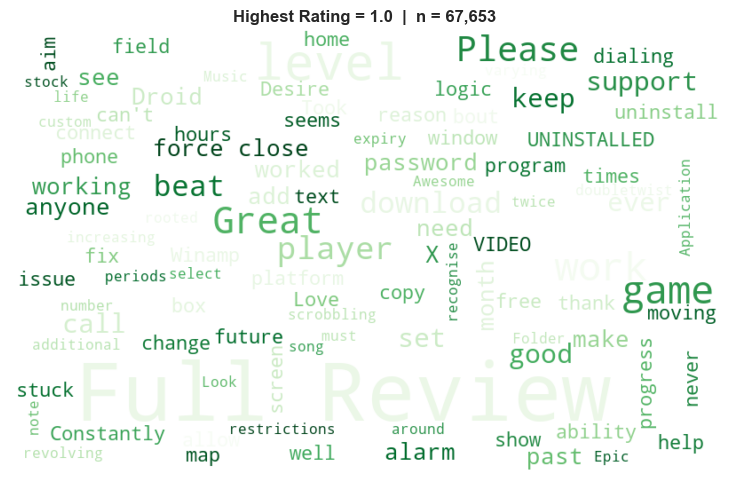

In [85]:
max_rating = df['reviewerRating'].max()

text_high = ' '.join(
    df[df['reviewerRating'] == min_rating]['reviewText'].astype(str).values
)

wc_high = WordCloud(
    width=800,
    height=500,
    background_color='white',
    stopwords=stop_words,
    max_words=100,
    colormap='Greens',
    random_state=42
).generate(text_high)

plt.figure(figsize=(8, 5))
plt.imshow(wc_high, interpolation='bilinear')
plt.title(f'Highest Rating = {max_rating}  |  n = {len(df[df["reviewerRating"]==max_rating]):,}',
          fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()